# Импорт библиотек

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import LabelSpreading

pd.set_option('display.max_colwidth', 120)

# Загрузка данных

In [44]:
INPUT_CSV = Path('text_embs.csv')
OUTPUT_CSV = INPUT_CSV.with_name('text_embs_labeled.csv')

In [45]:
df = pd.read_csv(INPUT_CSV)
feature_cols = [f'e{i}' for i in range(1, 6)]

In [46]:
print(f'Файл: {INPUT_CSV}')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print('Пропуски по столбцам:')
print(df.isna().sum())

Файл: text_embs.csv
Размер датасета: 43 строк, 7 столбцов
Пропуски по столбцам:
id              0
article_text    0
e1              0
e2              0
e3              0
e4              0
e5              0
dtype: int64


In [47]:
df = df.drop(columns="id")

In [48]:
df.head()

,article_text,e1,e2,e3,e4,e5
0,Spin me round: Conceptual image of the distant galaxy MACS1149-JD1 forming and spinning up to speed in the early uni...,-22.158750,0.724839,0.288074,-4.338476,-78.955190
1,"Euclid mission releases its first images\nThe Euclid mission, which will investigate the mysteries of dark matter an...",-69.417400,35.862324,-0.087313,-4.319662,71.955670
2,"This colourful stripe of stars, gas, and dust is actually a spiral galaxy named NGC 1055. Captured here by ESO’s Ver...",-19.161320,16.865223,0.275305,-4.339422,-95.052050
3,Scientists say they are stunned after discovering sea spiders have the ability to grow new reproductive organs and a...,39.257393,-0.624030,-0.312458,-3.406152,15.344043
4,Just a few swabs from a handful of leaves can say a lot about what animals are roaming in the area.\nTwo dozen leaf ...,77.716700,-10.334601,-0.358630,-3.616157,35.430443


# Ручная seed-разметка

Размечены только очевидные примеры, где тема прямо видна из текста:
- `космос`: тексты про галактики, Euclid/JWST, тёмную материю и карту космоса;
- `биология`: тексты про морских пауков, eDNA, сон/иммунный ответ и ехидн.
Остальные объекты остаются с меткой `-1` и размечаются алгоритмом SSL.

In [49]:
manual_seed_labels = {
    # Космос
    0: 'cosmos',    # distant galaxy MACS1149-JD1
    1: 'cosmos',    # Euclid mission, dark matter/dark energy
    17: 'cosmos',   # James Webb Space Telescope / dawn of the universe
    34: 'cosmos',   # map of the cosmos / dark matter

    # Биология
    4: 'biology',  # sea spiders and regeneration
    5: 'biology',  # environmental DNA from leaves
    8: 'biology',  # sleep and immune response to vaccination
    16: 'biology', # echidnas and thermoregulation
}


In [50]:
seed_report = (
    df.loc[df.index.isin(manual_seed_labels), ['article_text']]
      .assign(seed_label=lambda x: x.index.map(manual_seed_labels))
      .sort_values(['seed_label'])
)
seed_report['text_preview'] = seed_report['article_text'].str.replace('\n', ' ', regex=False).str.slice(0, 180)
seed_report[['seed_label', 'text_preview']]

,seed_label,text_preview
4,biology,Just a few swabs from a handful of leaves can say a lot about what animals are roaming in the area. Two dozen leaf s...
5,biology,"Standing on the marina, Rob Skelly peers into the darkness of the river where bright speckles of algae drift in the ..."
8,biology,"In a former gold mine a mile underground, inside a titanium tank filled with a rare liquified gas, scientists have b..."
16,biology,Current estimates of Lake Erie algae toxicity may miss the mark Study suggests harmful algal bloom toxicity varies o...
0,cosmos,Spin me round: Conceptual image of the distant galaxy MACS1149-JD1 forming and spinning up to speed in the early uni...
1,cosmos,"Euclid mission releases its first images The Euclid mission, which will investigate the mysteries of dark matter and..."
17,cosmos,"This image provided by NASA on Monday, July 11, 2022, shows galaxy cluster SMACS 0723, captured by the James Webb Sp..."
34,cosmos,"A new map of the cosmos shows the distribution of mysterious dark matter in sharp detail. The map, which covers a qu..."


# SSL-модель

Используется `LabelSpreading` с KNN-графом по стандартизированным координатам эмбеддингов. Стандартизация нужна, потому что координаты `e1`–`e5` имеют разные масштабы; без неё расстояния будут чрезмерно зависеть от координат с большим численным диапазоном.


In [51]:
label_to_int = {'biology': 0, 'cosmos': 1}
int_to_label = {v: k for k, v in label_to_int.items()}

In [52]:
X = df[feature_cols].to_numpy()
X_scaled = StandardScaler().fit_transform(X)

Визуализация ручной разметки

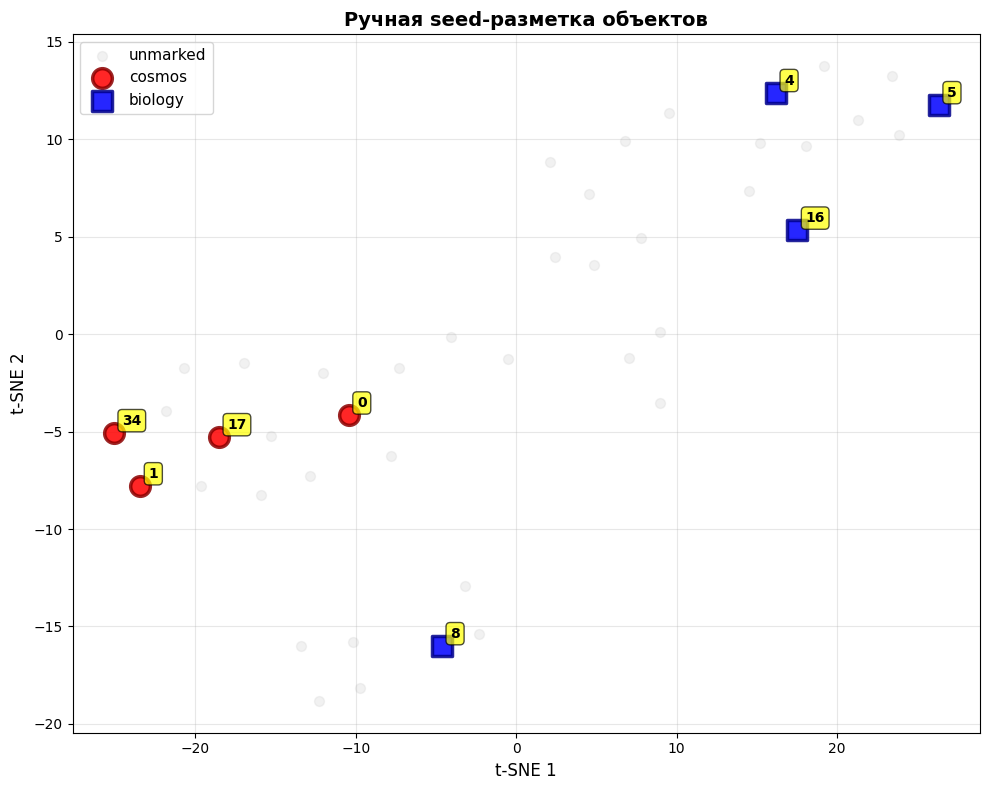

Всего размеченных объектов: 8
  cosmos: 4 объектов
  biology: 4 объектов


In [53]:
tsne_seed = TSNE(n_components=2, random_state=42, perplexity=10, max_iter=1000)
X_tsne_seed = tsne_seed.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))

seed_indices = list(manual_seed_labels.keys())
all_indices = set(range(len(df)))
unmapped_indices = list(all_indices - set(seed_indices))

ax.scatter(X_tsne_seed[unmapped_indices, 0], X_tsne_seed[unmapped_indices, 1], 
          c='lightgray', alpha=0.3, s=50, label='unmarked', zorder=1)

cosmos_seed_mask = np.array([i in seed_indices and manual_seed_labels[i] == 'cosmos' for i in range(len(df))])
biology_seed_mask = np.array([i in seed_indices and manual_seed_labels[i] == 'biology' for i in range(len(df))])

cosmos_indices = np.where(cosmos_seed_mask)[0]
biology_indices = np.where(biology_seed_mask)[0]

ax.scatter(X_tsne_seed[cosmos_indices, 0], X_tsne_seed[cosmos_indices, 1], 
          c='red', s=200, alpha=0.85, marker='o', edgecolors='darkred', linewidth=2.5, 
          label='cosmos', zorder=3)
ax.scatter(X_tsne_seed[biology_indices, 0], X_tsne_seed[biology_indices, 1], 
          c='blue', s=200, alpha=0.85, marker='s', edgecolors='darkblue', linewidth=2.5, 
          label='biology', zorder=3)

for idx in seed_indices:
    ax.annotate(str(idx), (X_tsne_seed[idx, 0], X_tsne_seed[idx, 1]), 
               xytext=(6, 6), textcoords='offset points', fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('Ручная seed-разметка объектов', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Всего размеченных объектов: {len(seed_indices)}')
print(f'  cosmos: {len(cosmos_indices)} объектов')
print(f'  biology: {len(biology_indices)} объектов')

In [54]:
y = pd.Series(-1, index=df.index, dtype='int64')
for obj_id, label in manual_seed_labels.items():
    idx = df.index[df.index == obj_id]
    if len(idx) != 1:
        raise ValueError(f'id={obj_id} должен встречаться в датасете ровно один раз')
    y.iloc[idx[0]] = label_to_int[label]

In [55]:
model = LabelSpreading(
    kernel='knn',
    n_neighbors=15,
    alpha=0.2,
    max_iter=1000,
)
model.fit(X_scaled, y.to_numpy())

,"kernel kernel: {'knn', 'rbf'} or callable, default='rbf'String identifier for kernel function to use or the kernel functionitself. Only 'rbf' and 'knn' strings are valid inputs. The functionpassed should take two inputs, each of shape (n_samples, n_features),and return a (n_samples, n_samples) shaped weight matrix.",'knn'
,"gamma gamma: float, default=20Parameter for rbf kernel.",20
,"n_neighbors n_neighbors: int, default=7Parameter for knn kernel which is a strictly positive integer.",15
,"alpha alpha: float, default=0.2Clamping factor. A value in (0, 1) that specifies the relative amountthat an instance should adopt the information from its neighbors asopposed to its initial label.alpha=0 means keeping the initial label information; alpha=1 meansreplacing all initial information.",0.2
,"max_iter max_iter: int, default=30Maximum number of iterations allowed.",1000
,"tol tol: float, default=1e-3Convergence tolerance: threshold to consider the system at steadystate.",0.001
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [56]:
pred = model.transduction_
pred_labels = [int_to_label[int(v)] for v in pred]

In [57]:
result = df.copy()
result['class_label'] = pred_labels

result[['class_label']].head(10)

,class_label
0,cosmos
1,cosmos
2,cosmos
3,biology
4,biology
5,biology
6,biology
7,cosmos
8,biology
9,biology


# Контроль результата

Визуализация результатов

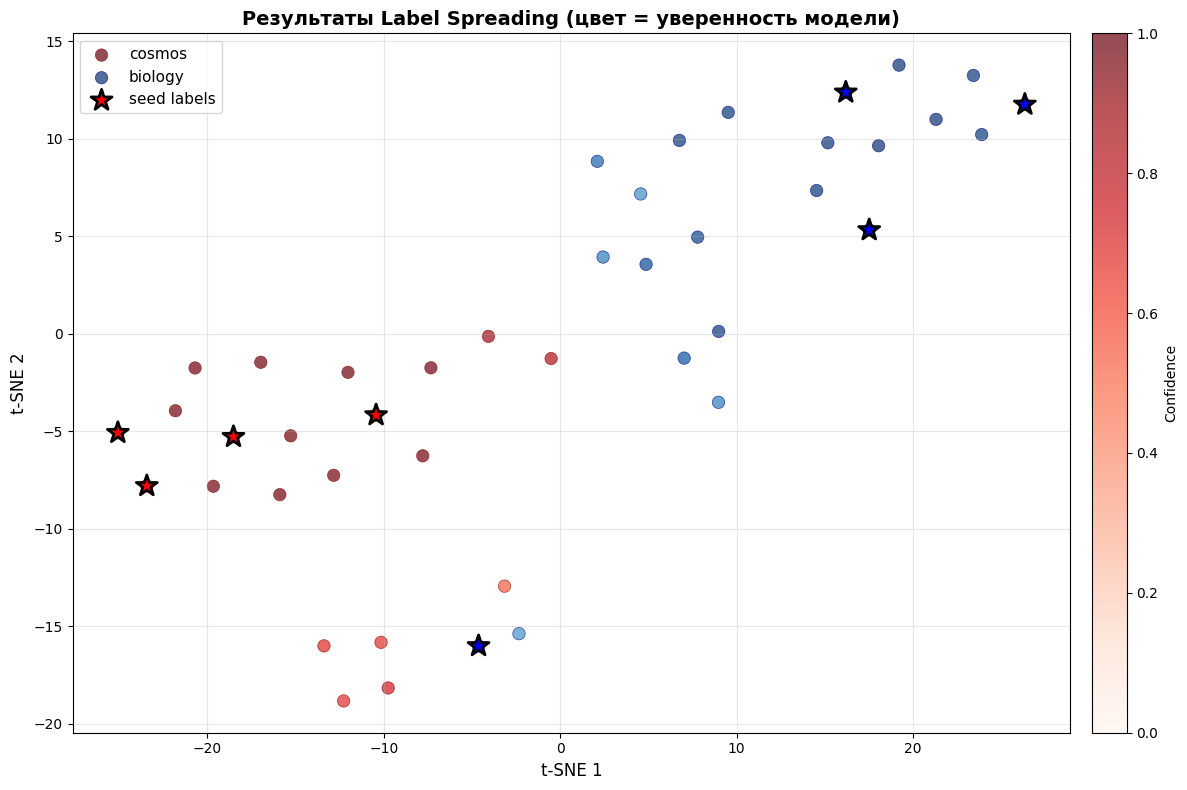

Распределение SSL предсказаний:
  cosmos: 21 объектов
  biology: 22 объектов

Средняя уверенность по классам:
  cosmos: 0.898
  biology: 0.901


In [58]:
tsne_ssl = TSNE(n_components=2, random_state=42, perplexity=10, max_iter=1000)
X_tsne_ssl = tsne_ssl.fit_transform(X_scaled)

classes = list(model.classes_)
assigned_confidence = []
for i, cls in enumerate(pred):
    assigned_confidence.append(float(model.label_distributions_[i, classes.index(cls)]))

fig, ax = plt.subplots(figsize=(12, 8))

cosmos_ssl_mask = np.array([label == 'cosmos' for label in pred_labels])
biology_ssl_mask = np.array([label == 'biology' for label in pred_labels])

cosmos_ssl_indices = np.where(cosmos_ssl_mask)[0]
biology_ssl_indices = np.where(biology_ssl_mask)[0]

cosmos_conf = [assigned_confidence[i] for i in cosmos_ssl_indices]
biology_conf = [assigned_confidence[i] for i in biology_ssl_indices]

scatter_cosmos = ax.scatter(X_tsne_ssl[cosmos_ssl_indices, 0], X_tsne_ssl[cosmos_ssl_indices, 1],
                            c=cosmos_conf, cmap='Reds', s=80, alpha=0.7, edgecolors='darkred', 
                            linewidth=0.5, label='cosmos', vmin=0, vmax=1)
scatter_biology = ax.scatter(X_tsne_ssl[biology_ssl_indices, 0], X_tsne_ssl[biology_ssl_indices, 1],
                             c=biology_conf, cmap='Blues', s=80, alpha=0.7, edgecolors='darkblue', 
                             linewidth=0.5, label='biology', vmin=0, vmax=1)

seed_indices = list(manual_seed_labels.keys())
seed_colors_ssl = np.array(['red' if pred_labels[i] == 'cosmos' else 'blue' for i in seed_indices])
ax.scatter(X_tsne_ssl[seed_indices, 0], X_tsne_ssl[seed_indices, 1],
          c=seed_colors_ssl, s=250, alpha=1.0, marker='*', edgecolors='black', 
          linewidth=2, label='seed labels', zorder=5)

ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('Результаты Label Spreading (цвет = уверенность модели)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter_cosmos, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label('Confidence', fontsize=10)

plt.tight_layout()
plt.show()

print(f'Распределение SSL предсказаний:')
print(f'  cosmos: {len(cosmos_ssl_indices)} объектов')
print(f'  biology: {len(biology_ssl_indices)} объектов')
print(f'\nСредняя уверенность по классам:')
print(f'  cosmos: {np.mean(cosmos_conf):.3f}')
print(f'  biology: {np.mean(biology_conf):.3f}')

In [59]:
for obj_id, label in manual_seed_labels.items():
    assigned = result.loc[result.index == obj_id, 'class_label'].iloc[0]
    assert assigned == label, f'id={obj_id}: ожидалась seed-метка {label}, получено {assigned}'

In [60]:
classes = list(model.classes_)
assigned_confidence = []
for i, cls in enumerate(pred):
    assigned_confidence.append(float(model.label_distributions_[i, classes.index(cls)]))

In [61]:
audit = result[['class_label']].copy()
audit['was_seed'] = audit.index.isin(manual_seed_labels)
audit['ssl_confidence'] = np.round(assigned_confidence, 3)
audit['text_preview'] = df['article_text'].str.replace('\n', ' ', regex=False).str.slice(0, 120)

In [62]:
print('Распределение классов:')
print(result['class_label'].value_counts())

Распределение классов:
class_label
biology    22
cosmos     21
Name: count, dtype: int64


In [63]:
audit

,class_label,was_seed,ssl_confidence,text_preview
0,cosmos,True,0.999,Spin me round: Conceptual image of the distant galaxy MACS1149-JD1 forming and spinning up to speed in the early uni...
1,cosmos,True,0.984,"Euclid mission releases its first images The Euclid mission, which will investigate the mysteries of dark matter and..."
2,cosmos,False,0.987,"This colourful stripe of stars, gas, and dust is actually a spiral galaxy named NGC 1055. Captured here by ESO’s Ver..."
3,biology,False,0.989,Scientists say they are stunned after discovering sea spiders have the ability to grow new reproductive organs and a...
4,biology,True,0.999,Just a few swabs from a handful of leaves can say a lot about what animals are roaming in the area. Two dozen leaf s...
5,biology,True,0.982,"Standing on the marina, Rob Skelly peers into the darkness of the river where bright speckles of algae drift in the ..."
6,biology,False,0.615,"The James Webb space telescope has detected what appear to be six massive ancient galaxies, which astronomers are ca..."
7,cosmos,False,0.840,"We all know how important sleep is for mental health, but a meta-analysis publishing in the journal Current Biology ..."
8,biology,True,0.963,"In a former gold mine a mile underground, inside a titanium tank filled with a rare liquified gas, scientists have b..."
9,biology,False,0.968,Molecular scale structure and kinetics of layer-by-layer peptide self-organization at atomically flat solid surfaces...


# Сохранение CSV

In [ ]:
result.to_csv(OUTPUT_CSV, index=False)
print(f'Сохранено: {OUTPUT_CSV}')
print(f'Размер результата: {result.shape[0]} строк, {result.shape[1]} столбцов')

Сохранено: text_embs_labeled.csv
Размер результата: 43 строк, 7 столбцов
